In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter
from scipy.fft import fft, fftfreq


Ошибка: данных слишком мало для фильтра. Длина данных: 0


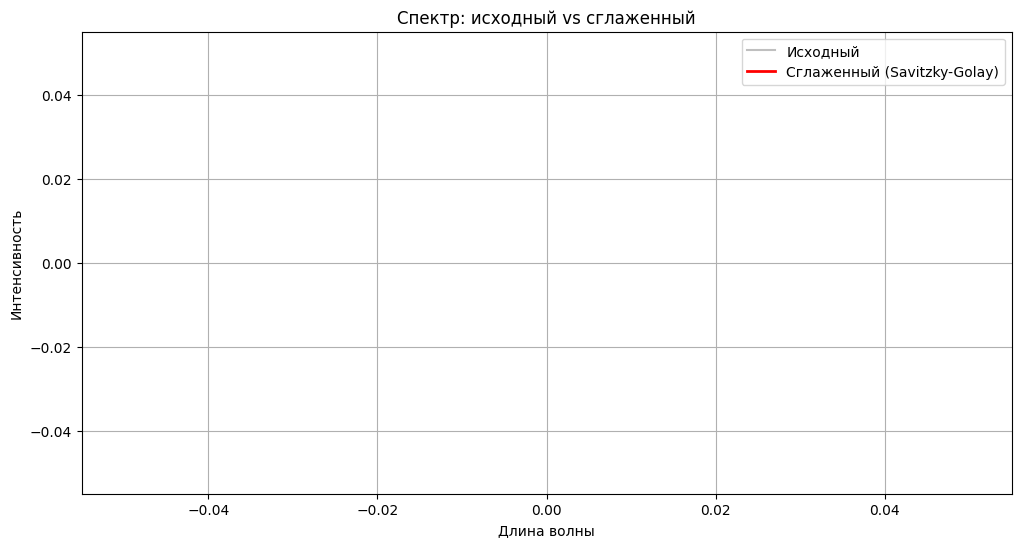

Готово! Данные загружены и обработаны.


In [35]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter

# --- 1. ЧИТАЕМ ФАЙЛ КАК ОБЫЧНЫЙ ТЕКСТ ---
with open(r'C:\Users\sasha\OneDrive\Рабочий стол\Dspectrum analysis\data\spectrum.csv', 'r', encoding='utf-8', errors='ignore') as f:
    lines = f.readlines()

# --- 2. ВЫТАСКИВАЕМ ЧИСЛА ВРУЧНУЮ ---
x_data = []
y_data = []

for line in lines:
    parts = line.strip().split()
    if len(parts) >= 2:
        try:
            val1 = float(parts[0])
            val2 = float(parts[1])
            x_data.append(val1)
            y_data.append(val2)
        except:
            pass

# --- 3. СОЗДАЁМ DATAFRAME И ПЕРЕМЕННЫЕ x, y ---
df_clean = pd.DataFrame({
    'Wavelength': x_data,
    'Intensity': y_data
})

x = df_clean['Wavelength']
y = df_clean['Intensity']

# --- 4. ПРИМЕНЯЕМ ФИЛЬТР САВИЦКОГО-ГОЛЕЯ ---
window_length = 11  # Должно быть нечётным числом
if len(y) > window_length:
    filtered = savgol_filter(y, window_length=window_length, polyorder=3)
else:
    print(f"Ошибка: данных слишком мало для фильтра. Длина данных: {len(y)}")
    filtered = y  # Если данных мало, берём как есть

# --- 5. СТРОИМ ГРАФИК ИСХОДНОГО И СГЛАЖЕННОГО ---
plt.figure(figsize=(12, 6))
plt.plot(x, y, label='Исходный', alpha=0.5, color='gray')
plt.plot(x, filtered, label='Сглаженный (Savitzky-Golay)', color='red', linewidth=2)
plt.xlabel('Длина волны')
plt.ylabel('Интенсивность')
plt.legend()
plt.grid(True)
plt.title('Спектр: исходный vs сглаженный')
plt.show()

print("Готово! Данные загружены и обработаны.")

Загружено 0 точек данных.
ОШИБКА: Данные не загружены! Проверьте формат файла.
Внимание: данных слишком мало для фильтра (0).


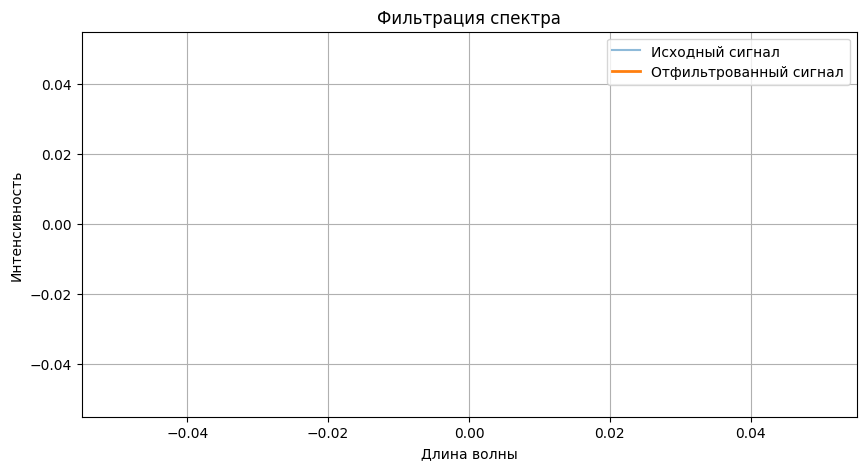

ОШИБКА: Нет данных для FFT.
Всё выполнено успешно!


: 

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter
import numpy as np
from numpy.fft import fft, fftfreq
import os

# --- 1. ЗАГРУЗКА ДАННЫХ С ПРАВИЛЬНОЙ ОБРАБОТКОЙ ЗАПЯТЫХ ---
file_path = r'C:\Users\sasha\OneDrive\Рабочий стол\Dspectrum analysis\data\spectrum.csv'

# Читаем файл, заменяя запятые на точки, и убираем пустые строки
with open(file_path, 'r', encoding='utf-8', errors='ignore') as f:
    lines = f.readlines()

x_data = []
y_data = []

for line in lines:
    line = line.strip()
    if not line:  # Пропускаем пустые строки
        continue
    
    # Разбиваем по пробелам или табуляции
    parts = line.split()
    if len(parts) >= 2:
        try:
            # Заменяем запятую на точку (важно для ваших данных!)
            val1_str = parts[0].replace(',', '.')
            val2_str = parts[1].replace(',', '.')
            
            val1 = float(val1_str)
            val2 = float(val2_str)
            
            x_data.append(val1)
            y_data.append(val2)
        except ValueError:
            # Если не получается преобразовать в число - пропускаем
            continue

# --- 2. СОЗДАНИЕ DATAFRAME И ПЕРЕМЕННЫХ ---
df_clean = pd.DataFrame({
    'Wavelength': x_data,
    'Intensity': y_data
})

x = df_clean['Wavelength']
y = df_clean['Intensity']

print(f"Загружено {len(x)} точек данных.")

if len(x) == 0:
    print("ОШИБКА: Данные не загружены! Проверьте формат файла.")
    exit()

# --- 3. ПРИМЕНЕНИЕ ФИЛЬТРА САВИЦКОГО-ГОЛЕЯ ---
window_length = 11
if len(y) >= window_length:
    filtered = savgol_filter(y, window_length=window_length, polyorder=3)
else:
    filtered = y.values
    print(f"Внимание: данных слишком мало для фильтра ({len(y)}).")

# --- 4. ГРАФИК 1: ИСХОДНЫЙ И ОТФИЛЬТРОВАННЫЙ ---
plt.figure(figsize=(10, 5))
plt.plot(x, y, label='Исходный сигнал', alpha=0.5)
plt.plot(x, filtered, label='Отфильтрованный сигнал', linewidth=2)
plt.title('Фильтрация спектра')
plt.xlabel('Длина волны')
plt.ylabel('Интенсивность')
plt.legend()
plt.grid(True)

os.makedirs('../results', exist_ok=True)
plt.savefig('../results/filtered_signal.png')
plt.show()

# --- 5. БЫСТРОЕ ПРЕОБРАЗОВАНИЕ ФУРЬЕ ---
N = len(filtered)
T = 1.0  # Интервал между точками

if N == 0:
    print("ОШИБКА: Нет данных для FFT.")
else:
    spectrum = fft(filtered)
    frequencies = fftfreq(N, T)

    plt.figure(figsize=(10, 5))
    plt.plot(frequencies[:N//2], np.abs(spectrum[:N//2]))
    plt.title('Спектр частот (FFT)')
    plt.xlabel('Частота')
    plt.ylabel('Амплитуда')
    plt.grid(True)
    plt.savefig('../results/spectrum_plot.png')
    plt.show()

print("Всё выполнено успешно!")